# Practical 1: Cell segmentation with Cellpose

**ELIXIR Spatial Omics 2026**

In this practical we segment cells in a Xenium morphology image using
[Cellpose](https://cellpose.readthedocs.io/), assign transcripts to the
segmented cells, and compare our segmentation against the segmentation
shipped by 10x Genomics.

The data is the cropped Xenium mouse brain dataset produced in **Practical 0**
(`Xenium_V1_FFPE_TgCRND8_17_9_months_cropped.zarr`). It is stored as a
[SpatialData](https://spatialdata.scverse.org/) object, which bundles the
images, the 10x segmentation masks, the transcripts and the cell-by-gene
table into a single object with a shared coordinate system.

Adpated from Practical 1: Segmentation of spatial transcriptomics data using cellpose Date: 2025-01-22

## 1. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as sd

from cellpose import models, plot
from skimage.measure import regionprops_table
from skimage.transform import resize
from sklearn.metrics import jaccard_score

sns.set_theme(style="whitegrid")
%matplotlib inline

### Load the data


In [2]:
from pathlib import Path

ZARR_PATH = Path("../data/Xenium_V1_FFPE_TgCRND8_17_9_months_cropped.zarr")


sdata = sd.read_zarr(ZARR_PATH)
sdata

SpatialData object, with associated Zarr store: /home/sugsi131/sco-work/data/Xenium_V1_FFPE_TgCRND8_17_9_months_cropped.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 5559, 7009), (1, 2780, 3505), (1, 1390, 1753), (1, 695, 876), (1, 348, 438)
│     └── 'morphology_mip': DataTree[cyx] (1, 5559, 7009), (1, 2780, 3505), (1, 1390, 1753), (1, 695, 876), (1, 348, 438)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (5559, 7009), (2780, 3505), (1390, 1753), (695, 876), (348, 438)
│     └── 'nucleus_labels': DataTree[yx] (5559, 7009), (2780, 3505), (1390, 1753), (695, 876), (348, 438)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (4605, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (4507, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (4605, 347)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip 

The object contains:

| Element | What it is |
|---|---|
| `images/morphology_mip` | maximum-intensity projection of the morphology stain |
| `images/morphology_focus` | best-focus plane of the same stain |
| `labels/cell_labels` | 10x whole-cell segmentation, as a label image |
| `labels/nucleus_labels` | 10x nuclear segmentation, as a label image |
| `points/transcripts` | every detected transcript, with its coordinates |
| `shapes/cell_boundaries` | 10x cell outlines, as polygons |
| `tables/table` | the cell-by-gene count matrix (AnnData) |

Note that the images are stored as **multiscale pyramids** — several
progressively downsampled copies of the same image (`scale0` is full
resolution, `scale1` is half, and so on). This lets us work at a coarser
resolution when we want speed, without loading a different file.

## 2. Choosing a resolution


In [3]:
SCALE_LEVEL = 0
SCALE_KEY = f"scale{SCALE_LEVEL}"

# Every pyramid level is stored as a small dataset with one variable, "image".
img_multiscale = sdata.images["morphology_mip"]
image_channel = img_multiscale[SCALE_KEY]["image"].data[0].compute()
image_channel = image_channel.astype(np.uint16)

full_shape = img_multiscale["scale0"]["image"].shape[-2:]
print(f"Full resolution : {full_shape[0]} x {full_shape[1]}")
print(f"Working at {SCALE_KEY} : {image_channel.shape[0]} x {image_channel.shape[1]}")

Full resolution : 5559 x 7009
Working at scale0 : 5559 x 7009


### How big is a pixel?

The transcripts are stored in microns, but `masks` is indexed in pixels, so we
need the conversion factor.

Xenium images have a pixel size of 0.2125 µm at full resolution. We are working
at a downsampled pyramid level, so the effective pixel size is larger by
exactly the downsampling factor — which we can read off the image shapes.

Getting this wrong shifts every transcript relative to the cells, and the
resulting plot still looks plausible. It is worth a moment to check.

In [4]:
PIXEL_SIZE_UM = 0.2125  # Xenium pixel size at full resolution
shrink = img_multiscale["scale0"]["image"].shape[-1] / image_channel.shape[-1]

x_scale = y_scale = 1 / (PIXEL_SIZE_UM * shrink)
print(f"{x_scale:.4f} pixels per micron  (scale{SCALE_LEVEL}, {shrink:.0f}x downsampled)")

4.7059 pixels per micron  (scale0, 1x downsampled)


### Look at the image before segmenting it

Always eyeball the input. If the contrast is poor or the wrong channel has been
selected, Cellpose will produce confident nonsense and you will not notice
until much later.

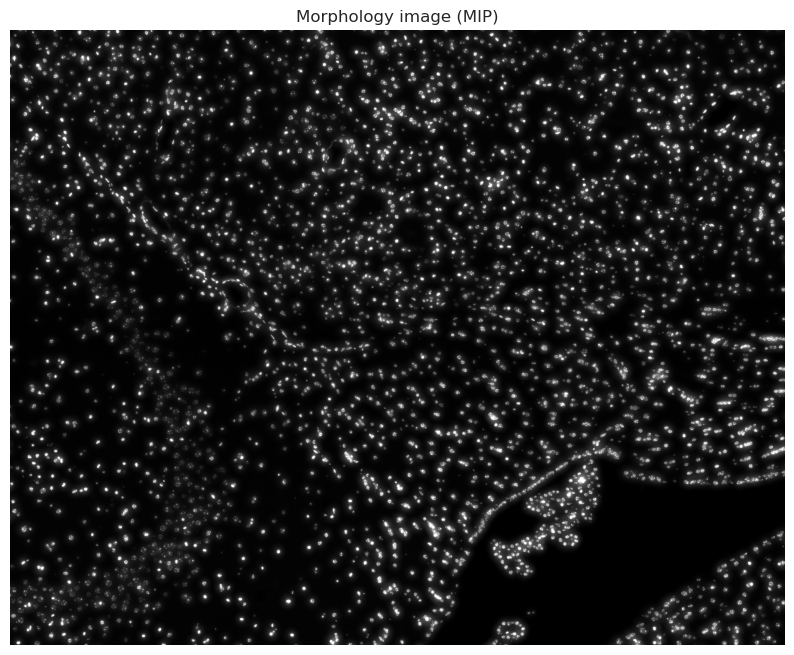

In [5]:
vmin, vmax = np.percentile(image_channel, [1, 99.5])

plt.figure(figsize=(10, 8))
plt.imshow(image_channel, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Morphology image (MIP)")
plt.axis("off")
plt.show()

## 3. Segmentation with Cellpose

Cellpose ships several pretrained models. `cyto3` is a general-purpose
cytoplasm model and a reasonable default for morphology stains like this one;
`nuclei` is the right choice if you only care about nuclei. Other options are
listed in the [Cellpose documentation](https://cellpose.readthedocs.io/).

The one parameter that really matters is `diameter`: the typical cell size in
**pixels**. Cellpose uses it to pick an internal scale, and a bad value is the
most common cause of poor results. Mouse brain cells are roughly 7–10 µm
across, so we convert 10 µm into pixels using the scale factor we just derived.

In [6]:
model = models.CellposeModel(gpu=False, model_type="cyto3")

In [7]:
cell_diameter_um = 10  # µm - adjust for your tissue
cell_diameter_pixels = cell_diameter_um * x_scale
print(f"Estimated cell diameter: {cell_diameter_pixels:.1f} pixels")

Estimated cell diameter: 47.1 pixels


**This cell takes several minutes.** It is the slow step of the practical —
a good moment to read ahead, or to look at the Cellpose documentation.

In [8]:
masks, flows, styles = model.eval(
    image_channel,
    diameter=cell_diameter_pixels,
)

print(f"Cells detected by Cellpose: {masks.max()}")

Cells detected by Cellpose: 3856


### Inspect the result

`show_segmentation` gives you the input, the predicted flows and the resulting
masks side by side. The flows are worth a look: they show *how* Cellpose
decided where the boundaries are, which often explains a bad segmentation
better than the masks do.

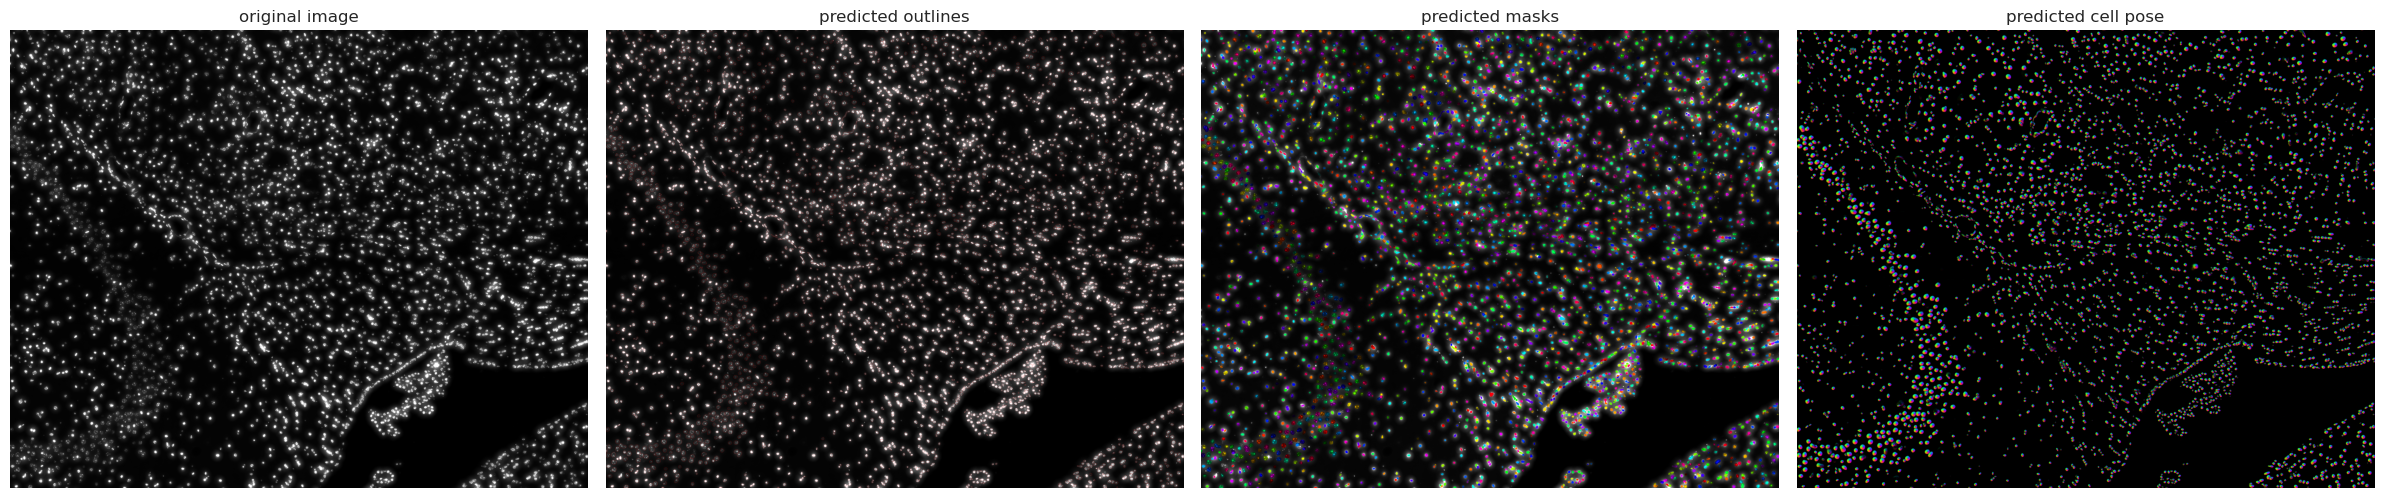

In [9]:
fig = plt.figure(figsize=(24, 8))
plot.show_segmentation(fig, image_channel, masks, flows[0])
plt.tight_layout()
plt.show()

## 4. Assigning transcripts to cells

Now we connect the imaging to the transcriptomics. Each transcript has a
position in microns; each pixel of `masks` carries a cell ID. Converting the
transcript coordinates into pixel indices lets us simply look up which cell —
if any — a transcript falls inside.

In [20]:
transcripts = sdata.transform_element_to_coordinate_system(
    "transcripts", "global"
).compute()

print(transcripts["x"].min(), transcripts["x"].max())

12169.00505514706 19177.996323529413


### Why we can't use these coordinates directly


`masks` (from Cellpose) is a plain pixel grid, indexed from `(0, 0)` at the
corner of the crop. So before we can look up `masks[row, col]` for a
transcript, we have to convert its real-world micrometer position into a pixel
position *relative to the crop* — the same shift that `spatialdata-plot` (the
`.pl` accessor you saw in Practical 0) does automatically whenever it draws
points and images together.


In [21]:
from spatialdata import get_extent

# 1. Where does the crop sit? (in micrometers, on the original slide)
extent = get_extent(sdata.images["morphology_mip"], coordinate_system="global")
x0, x1 = extent["x"]
y0, y1 = extent["y"]
print(f"crop spans x: {x0:.1f} - {x1:.1f} um")
print(f"crop spans y: {y0:.1f} - {y1:.1f} um")

height, width = masks.shape  # pixel size of the image we segmented

# 2 & 3. shift to crop-relative microns, then scale to pixels
x_indices = ((transcripts["x"].values - x0) / (x1 - x0) * width).astype(int)
y_indices = ((transcripts["y"].values - y0) / (y1 - y0) * height).astype(int)

crop spans x: 12169.0 - 19178.0 um
crop spans y: 9652.0 - 15211.0 um


In [22]:
# Keep only transcripts that land inside the image after conversion
inside = (
    (x_indices >= 0) & (x_indices < width) &
    (y_indices >= 0) & (y_indices < height)
)
print(f"{inside.sum():,} of {len(transcripts):,} transcripts fall inside the image")

transcripts = transcripts[inside].copy()
x_indices = x_indices[inside]
y_indices = y_indices[inside]

1,109,766 of 1,109,766 transcripts fall inside the image


If that count came back near zero, the shift-and-scale above did not run, or
`masks` is not the one you just produced with Cellpose. If it came back near
the full transcript count, you're good to continue.

Note this approach reads the pixel size directly from the image's own
width/height and micrometer extent, so it works unchanged whichever
`SCALE_LEVEL` you segmented at — no separate `x_scale` needed for this step.

In [23]:
transcripts["cellpose_cell_id"] = masks[y_indices, x_indices]

assigned = transcripts[transcripts["cellpose_cell_id"] > 0]
print(f"Assigned to a cell: {len(assigned):,} ({100 * len(assigned) / len(transcripts):.1f}%)")

Assigned to a cell: 327,334 (29.5%)


A large unassigned fraction is normal and interesting. Some transcripts
genuinely sit in extracellular space; others are lost because the segmentation
missed a cell or drew its boundary too tightly. This number is one of the more
honest measures of segmentation quality.

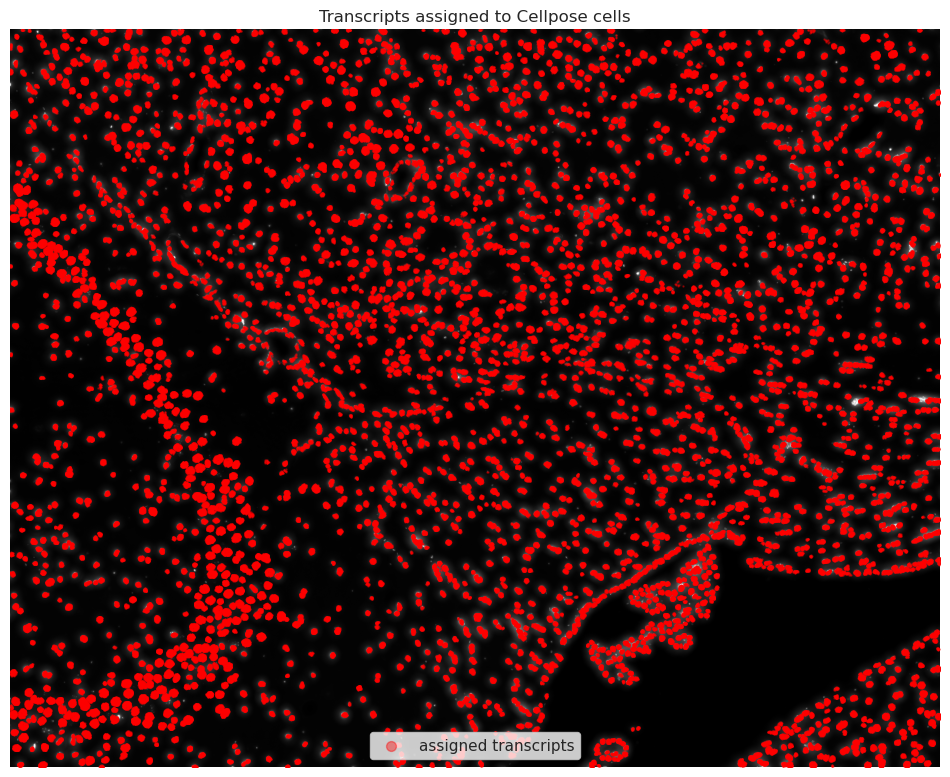

In [24]:
plt.figure(figsize=(12, 10))
plt.imshow(image_channel, cmap="gray", vmin=vmin, vmax=vmax)
plt.scatter(
    x_indices[transcripts["cellpose_cell_id"].values > 0],
    y_indices[transcripts["cellpose_cell_id"].values > 0],
    c="red", s=0.5, alpha=0.4, label="assigned transcripts",
)
plt.title("Transcripts assigned to Cellpose cells")
plt.axis("off")
plt.legend(markerscale=10)
plt.show()

### Build a cell-by-gene matrix

Counting transcripts per cell per gene gives us the expression matrix that all
downstream analysis is built on. This is, in essence, what the 10x pipeline
does — we have just done it with our own segmentation.

In [25]:
expression_matrix = (
    assigned
    .groupby(["cellpose_cell_id", "feature_name"])
    .size()
    .unstack(fill_value=0)
)

print(f"Expression matrix: {expression_matrix.shape[0]} cells x {expression_matrix.shape[1]} genes")
expression_matrix.iloc[:5, :5]

/tmp/ipykernel_71459/2604425076.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["cellpose_cell_id", "feature_name"])


Expression matrix: 3856 cells x 541 genes


feature_name,Sox10,Ctsh,Wfs1,Osmr,Fign
cellpose_cell_id,,,,,
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,1,0,0
5,0,0,0,0,0


### Plot a gene in space

Each cell is drawn at its centroid, coloured by the expression of one gene.

Showing: Plp1


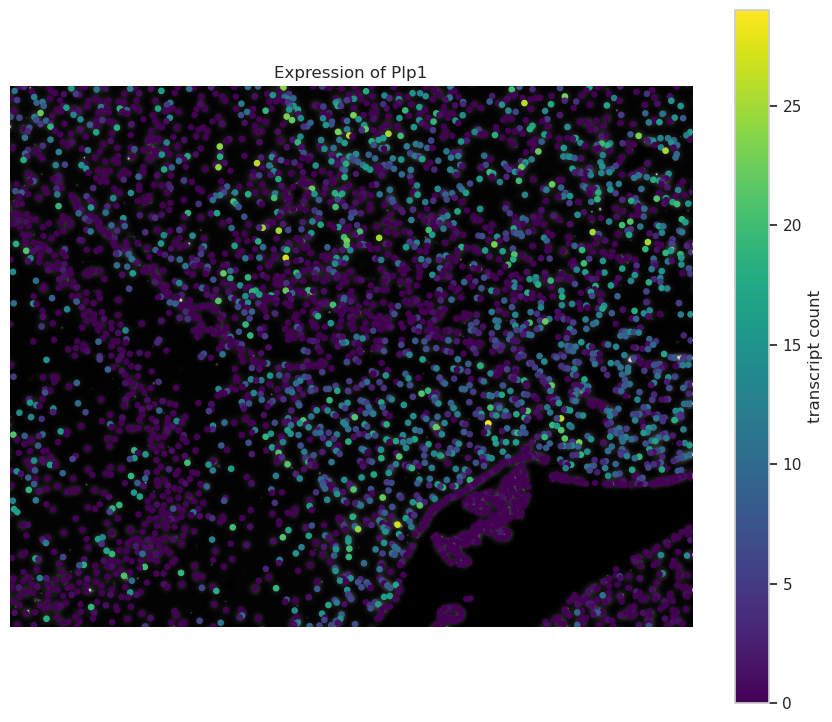

In [26]:
gene_of_interest = expression_matrix.sum().idxmax()  # the most-detected gene
print(f"Showing: {gene_of_interest}")

props = pd.DataFrame(regionprops_table(masks, properties=["label", "centroid"]))
props = props.set_index("label")

common = expression_matrix.index.intersection(props.index)
values = expression_matrix.loc[common, gene_of_interest].values
cy = props.loc[common, "centroid-0"].values
cx = props.loc[common, "centroid-1"].values

plt.figure(figsize=(11, 9))
plt.imshow(image_channel, cmap="gray", vmin=vmin, vmax=vmax)
sc = plt.scatter(cx, cy, c=values, cmap="viridis", s=14)
plt.colorbar(sc, label="transcript count")
plt.title(f"Expression of {gene_of_interest}")
plt.axis("off")
plt.show()

## 5. Comparing against the 10x segmentation

The dataset already contains 10x's own segmentation as a label image, on the
same pixel grid and with the same pyramid levels as the morphology image. That
makes the comparison straightforward — no polygon rasterisation needed.

We use the **nuclear** segmentation here because it is the part 10x derives
directly from the stain. Swap in `cell_labels` to compare whole-cell
boundaries instead.

In [27]:
ref_multiscale = sdata.labels["nucleus_labels"]
original_masks = ref_multiscale[SCALE_KEY]["image"].data.compute()

# Guard against any off-by-one between pyramid levels
if original_masks.shape != masks.shape:
    print(f"Resizing reference {original_masks.shape} -> {masks.shape}")
    original_masks = resize(
        original_masks, masks.shape, order=0,
        preserve_range=True, anti_aliasing=False,
    ).astype(original_masks.dtype)

print(f"Cellpose cells : {masks.max()}")
print(f"10x nuclei     : {original_masks.max()}")

Cellpose cells : 3856
10x nuclei     : 60637


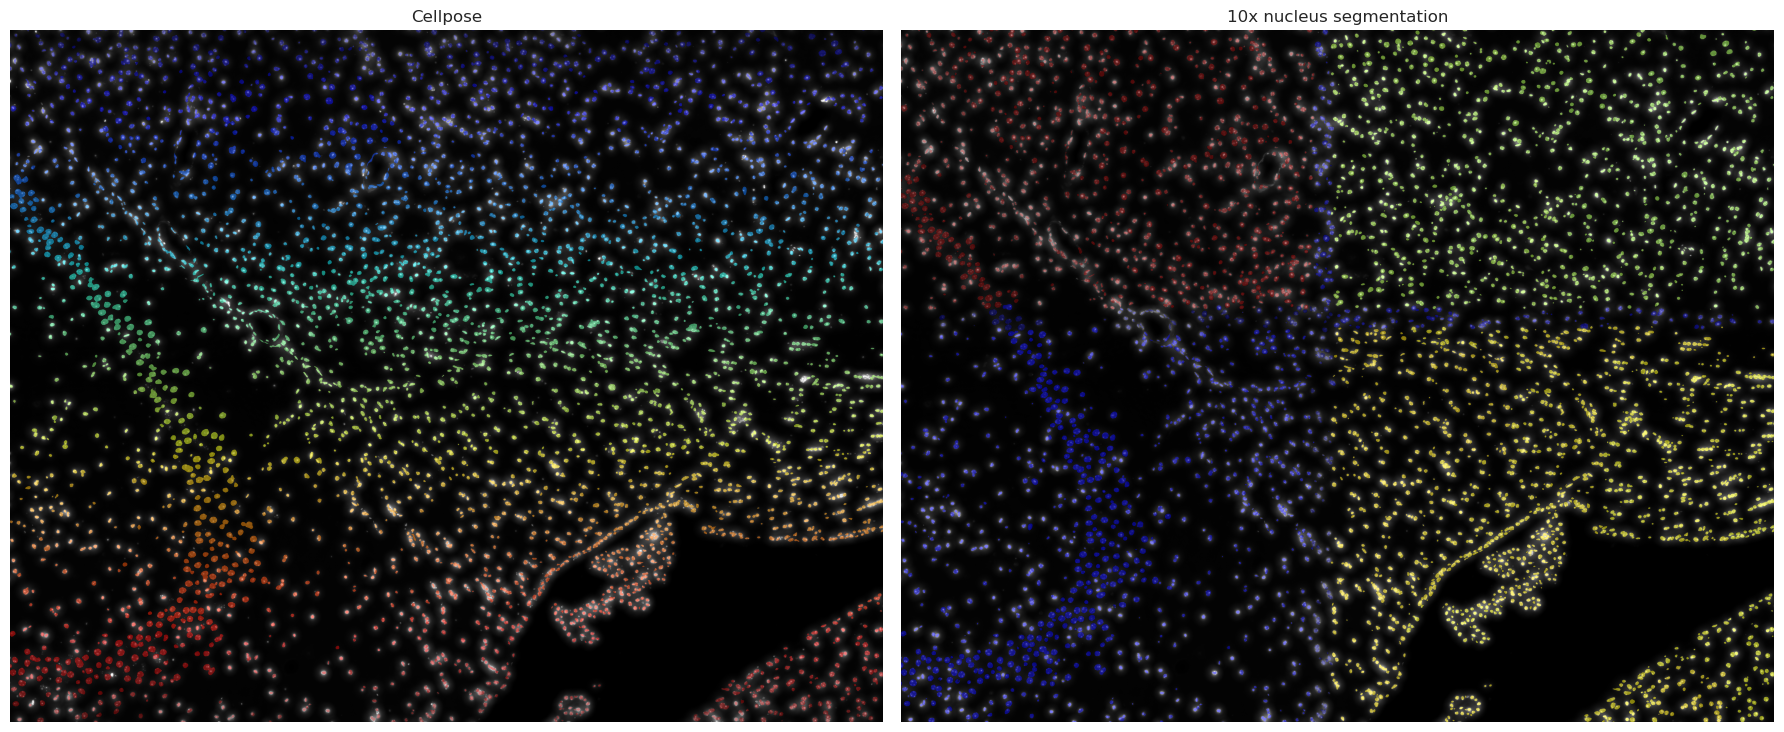

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(image_channel, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].imshow(np.ma.masked_where(masks == 0, masks), cmap="jet", alpha=0.5)
axes[0].set_title("Cellpose")
axes[0].axis("off")

axes[1].imshow(image_channel, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].imshow(np.ma.masked_where(original_masks == 0, original_masks), cmap="jet", alpha=0.5)
axes[1].set_title("10x nucleus segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Overlaying the two makes the disagreements easier to spot than viewing
them side by side. Purple regions are where both methods agree.

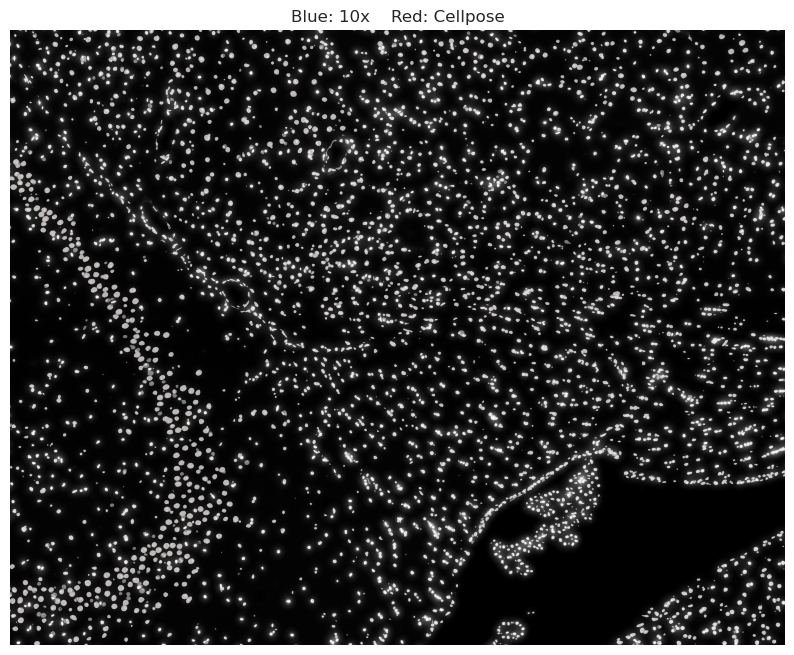

In [31]:
plt.figure(figsize=(10, 9))
plt.imshow(image_channel, cmap="gray", vmin=vmin, vmax=vmax)
plt.imshow(np.ma.masked_where(original_masks == 0, original_masks > 0),
           cmap="Blues", alpha=0.45)
plt.imshow(np.ma.masked_where(masks == 0, masks > 0),
           cmap="Reds", alpha=0.45)
plt.title("Blue: 10x    Red: Cellpose")
plt.axis("off")
plt.show()

### Quantifying the agreement

Two standard overlap measures, both computed on binary foreground/background
masks:

- **Jaccard index** (intersection over union) — the fraction of the combined
  foreground that both methods agree on.
- **Dice coefficient** — similar, but weights the intersection more heavily.
  Always the larger of the two.

Both ignore *identity*: they measure whether the same pixels are called
"cell", not whether the two methods split those pixels into the same cells.

In [32]:
cellpose_binary = (masks > 0).astype(np.uint8).ravel()
original_binary = (original_masks > 0).astype(np.uint8).ravel()

jaccard = jaccard_score(original_binary, cellpose_binary)
dice = 2 * jaccard / (1 + jaccard)   # Dice and Jaccard are related exactly

print(f"Jaccard index    : {jaccard:.4f}")
print(f"Dice coefficient : {dice:.4f}")

Jaccard index    : 0.8120
Dice coefficient : 0.8962


Do not read too much into a modest score. We compared whole cells against
nuclei, so Cellpose masks are *expected* to be larger. A low Jaccard here
reflects that difference in what is being segmented as much as any error.

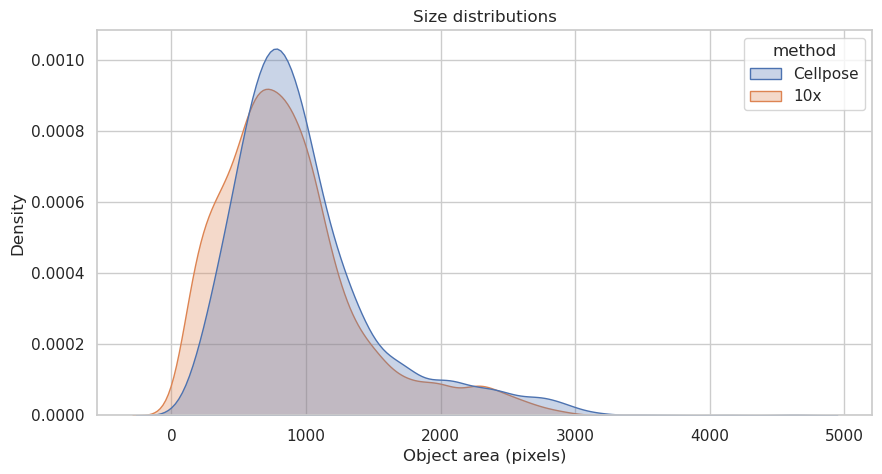

,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
10x,4505.0,875.190899,531.248059,8.0,514.00,792.0,1089.0,3425.0
Cellpose,3856.0,985.215508,553.540480,56.0,628.75,861.0,1176.0,4627.0


In [33]:
cellpose_areas = pd.DataFrame(regionprops_table(masks, properties=["area"]))
cellpose_areas["method"] = "Cellpose"

original_areas = pd.DataFrame(regionprops_table(original_masks, properties=["area"]))
original_areas["method"] = "10x"

areas_df = pd.concat([cellpose_areas, original_areas], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=areas_df, x="area", hue="method", common_norm=False, fill=True, alpha=0.3)
plt.xlabel("Object area (pixels)")
plt.title("Size distributions")
plt.show()

areas_df.groupby("method")["area"].describe()

## 6. Saving your results

Uncomment to write the masks and metrics out. Keeping the segmentation means
you can come back to it without re-running Cellpose.

In [ ]:
# import tifffile
# from pathlib import Path
#
# out = Path("results")
# out.mkdir(exist_ok=True)
#
# tifffile.imwrite(out / "cellpose_masks.tif", masks.astype(np.uint16))
# expression_matrix.to_csv(out / "cellpose_expression_matrix.csv")
# pd.DataFrame({
#     "metric": ["jaccard", "dice", "n_cellpose", "n_10x"],
#     "value": [jaccard, dice, masks.max(), original_masks.max()],
# }).to_csv(out / "segmentation_metrics.csv", index=False)

### A better way to save: back into the SpatialData object

Writing the masks as a labels element keeps them aligned with everything else
in the dataset, so later practicals can load them with the coordinate system
already attached.

In [ ]:
# from spatialdata.models import Labels2DModel
# from spatialdata.transformations import get_transformation, set_transformation
#
# labels = Labels2DModel.parse(masks, dims=("y", "x"))
# set_transformation(
#     labels,
#     get_transformation(sdata.labels["nucleus_labels"], to_coordinate_system="global"),
#     to_coordinate_system="global",
# )
# sdata.labels["cellpose_labels"] = labels
# sdata.write_element("cellpose_labels")

## Exercises

1. **Diameter sensitivity.** Re-run the segmentation with `cell_diameter_um`
   set to 5 and to 20. How does the cell count change, and does the Jaccard
   index track your visual impression of quality?

2. **Model choice.** Try `model_type="nuclei"` and compare against
   `nucleus_labels`. Does a model matched to the target do better than `cyto3`?

3. **Resolution.** If time allows, set `SCALE_LEVEL = 0` and segment at full
   resolution. Does the extra detail change the biology, or only the runtime?

4. **Unassigned transcripts.** Are the transcripts that fall outside every cell
   randomly distributed, or concentrated in particular regions or genes? What
   would either finding imply?

5. **Whole cells instead of nuclei.** Repeat the comparison against
   `cell_labels`. Does the Jaccard index improve, and does that match what you
   expected from the size distributions?